In [25]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import DeconV as dv

In [26]:
true_proportions = pd.read_csv("../../../fimm/data/pbmc/true.tsv", sep="\t", index_col=0)
true_proportions = true_proportions.sort_index(axis="columns").sort_index(axis="rows")
true_proportions.index.name = None
true_proportions

,B cells,Monocytes,NK,T CD4,T CD8,unknown
36TS_PBMC,0.06960,0.3153,0.0772,0.19150,0.17041,0.17599
453W_PBMC,0.05200,0.2166,0.0678,0.25332,0.28259,0.12769
4DUY_PBMC,0.07990,0.2225,0.0792,0.24223,0.12392,0.25225
684C_PBMC,0.10000,0.2219,0.0845,0.29714,0.15489,0.14157
925L_PBMC,0.15705,0.1966,0.0969,0.19423,0.18723,0.16799
9JD4_PBMC,0.08310,0.1698,0.0753,0.30033,0.23596,0.13551
CR3L_PBMC,0.11200,0.1596,0.1080,0.26843,0.15128,0.20069
CYFZ_PBMC,0.08390,0.1679,0.1400,0.17362,0.27818,0.15640
CZJE_PBMC,0.12900,0.2279,0.1580,0.19170,0.14691,0.14649
FLWA_PBMC,0.08390,0.2086,0.1950,0.23634,0.08345,0.19271


In [27]:
deconv_proportions = pd.read_csv("pbmc/nb/proportions_separate_bd.tsv", sep="\t", index_col=0)
deconv_proportions = deconv_proportions.sort_index(axis="columns").sort_index(axis="rows")
deconv_proportions

,B cells,Monocytes,NK,T CD4,T CD8,unknown
36TS_PBMC,0.012265,0.569149,0.156120,0.044242,0.129849,0.088376
453W_PBMC,0.019948,0.449609,0.200049,0.070531,0.176368,0.083494
4DUY_PBMC,0.022356,0.424671,0.199439,0.104198,0.165478,0.083858
684C_PBMC,0.023988,0.456022,0.153850,0.126954,0.157678,0.081508
925L_PBMC,0.027071,0.427818,0.176729,0.128453,0.157474,0.082455
9JD4_PBMC,0.022393,0.369434,0.197259,0.142438,0.178764,0.089713
CR3L_PBMC,0.026856,0.484408,0.152497,0.093626,0.156840,0.085772
CYFZ_PBMC,0.013067,0.413444,0.208758,0.106892,0.169537,0.088301
CZJE_PBMC,0.023011,0.480771,0.122067,0.130456,0.153675,0.090021
FLWA_PBMC,0.018299,0.447054,0.159819,0.098176,0.161447,0.115204


In [38]:
music_proportions = pd.read_csv("3rd-party/music/pbmc/music_proportions.csv", index_col=0)
music_proportions.rename(columns={"UNKWN": "unknown"}, inplace=True)
music_proportions = music_proportions.sort_index(axis="columns").sort_index(axis="rows")
music_proportions.index.name = None
music_proportions

,B.cells,Monocytes,NK,T.CD4,T.CD8,unknown
CR3L_PBMC,0.000000,0.215874,0.449245,0.112407,0.074853,0.147620
CYFZ_PBMC,0.000000,0.178609,0.553698,0.000000,0.107171,0.160523
CZJE_PBMC,0.000000,0.172202,0.498167,0.000000,0.091301,0.238331
FLWA_PBMC,0.000202,0.221343,0.491178,0.038089,0.091391,0.157797
FY2H_PBMC,0.000000,0.294299,0.502294,0.000000,0.006486,0.196921
G4YW_PBMC,0.004814,0.188954,0.479124,0.006311,0.151029,0.169770
X36TS_PBMC,0.000358,0.267792,0.470723,0.000000,0.015175,0.245953
X453W_PBMC,0.000442,0.137611,0.605237,0.005475,0.127747,0.123488
X4DUY_PBMC,0.000347,0.100114,0.553476,0.003583,0.124845,0.217635
X684C_PBMC,0.000000,0.172961,0.525961,0.003750,0.132002,0.165326


In [39]:
scaden_proportions = pd.read_csv("3rd-party/scaden/pbmc/scaden_predictions.txt", sep="\t", index_col=0)
scaden_proportions.index = pd.read_csv("3rd-party/scaden/pbmc/data/pbmc_bulk_data.txt", sep="\t", index_col=0).columns
scaden_proportions = scaden_proportions.sort_index(axis="columns").sort_index(axis="rows")
scaden_proportions

,B cells,Monocytes,NK,T CD4,T CD8,Unknown
36TS_PBMC,0.010037,0.420350,0.017120,0.546342,0.001835,0.004317
453W_PBMC,0.007028,0.309490,0.021084,0.656637,0.002861,0.002900
4DUY_PBMC,0.013468,0.276619,0.019817,0.686054,0.001632,0.002410
684C_PBMC,0.013789,0.275449,0.016786,0.688505,0.002550,0.002921
925L_PBMC,0.033514,0.289048,0.020525,0.650506,0.002946,0.003460
9JD4_PBMC,0.011647,0.257393,0.016891,0.709684,0.002075,0.002310
CR3L_PBMC,0.020417,0.280436,0.015686,0.679566,0.001115,0.002780
CYFZ_PBMC,0.016917,0.301009,0.026544,0.648776,0.003242,0.003512
CZJE_PBMC,0.025388,0.322172,0.030741,0.613584,0.002418,0.005697
FLWA_PBMC,0.013188,0.317955,0.025779,0.637466,0.002390,0.003221


In [40]:
melt = true_proportions.reset_index().melt(id_vars="index")
melt.rename(columns={"index": "sample", "value": "true", "variable":"cell_type"}, inplace=True)
melt["deconv"] = deconv_proportions.reset_index().melt(id_vars="index")["value"]
melt["scaden"] = scaden_proportions.reset_index().melt(id_vars="index")["value"]
melt["music"] = music_proportions.reset_index().melt(id_vars="index")["value"]
melt

,sample,cell_type,true,deconv,scaden,music
0,36TS_PBMC,B cells,0.06960,0.012265,0.010037,0.000000
1,453W_PBMC,B cells,0.05200,0.019948,0.007028,0.000000
2,4DUY_PBMC,B cells,0.07990,0.022356,0.013468,0.000000
3,684C_PBMC,B cells,0.10000,0.023988,0.013789,0.000202
4,925L_PBMC,B cells,0.15705,0.027071,0.033514,0.000000
...,...,...,...,...,...,...
67,CYFZ_PBMC,unknown,0.15640,0.088301,0.003512,0.123488
68,CZJE_PBMC,unknown,0.14649,0.090021,0.005697,0.217635
69,FLWA_PBMC,unknown,0.19271,0.115204,0.003221,0.165326
70,FY2H_PBMC,unknown,0.21210,0.098757,0.005989,0.201553


In [41]:
df = true_proportions.reset_index().melt(id_vars="index")
df.rename(columns={"index": "sample", "value": "proportion", "variable":"cell_type"}, inplace=True)
df["type"] = "true"
df["error"] = None
# # df["true"] = true_proportions.reset_index().melt(id_vars="index")["value"]
# df_true = true_proportions.reset_index().melt(id_vars="index")
# df_true.rename(columns={"index": "sample", "value": "proportion", "variable":"cell_type"}, inplace=True)
# df_true["type"] = "true"
# df = pd.concat([df_est, df_true])

melt["deconv_error"] = abs(melt["deconv"] - melt["true"])
melt["scaden_error"] = abs(melt["scaden"] - melt["true"])
melt["music_error"] = abs(melt["music"] - melt["true"])

temp = melt[["sample", "cell_type", "deconv", "deconv_error"]].rename(columns={"deconv": "proportion", "deconv_error": "error"})
temp["type"] = "deconv"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "scaden", "scaden_error"]].rename(columns={"scaden": "proportion", "scaden_error": "error"})
temp["type"] = "scaden"
df = pd.concat([df, temp])

temp = melt[["sample", "cell_type", "music", "music_error"]].rename(columns={"music": "proportion", "music_error": "error"})
temp["type"] = "music"
df = pd.concat([df, temp])

df

,sample,cell_type,proportion,type,error
0,36TS_PBMC,B cells,0.069600,true,NaN
1,453W_PBMC,B cells,0.052000,true,NaN
2,4DUY_PBMC,B cells,0.079900,true,NaN
3,684C_PBMC,B cells,0.100000,true,NaN
4,925L_PBMC,B cells,0.157050,true,NaN
...,...,...,...,...,...
67,CYFZ_PBMC,unknown,0.123488,music,0.032912
68,CZJE_PBMC,unknown,0.217635,music,0.071145
69,FLWA_PBMC,unknown,0.165326,music,0.027384
70,FY2H_PBMC,unknown,0.201553,music,0.010547


In [24]:
((melt["deconv"] - melt["true"])**2).mean()**0.5, ((melt["scaden"] - melt["true"])**2).mean()**0.5

(0.13041392949332728, 0.20678182833014538)

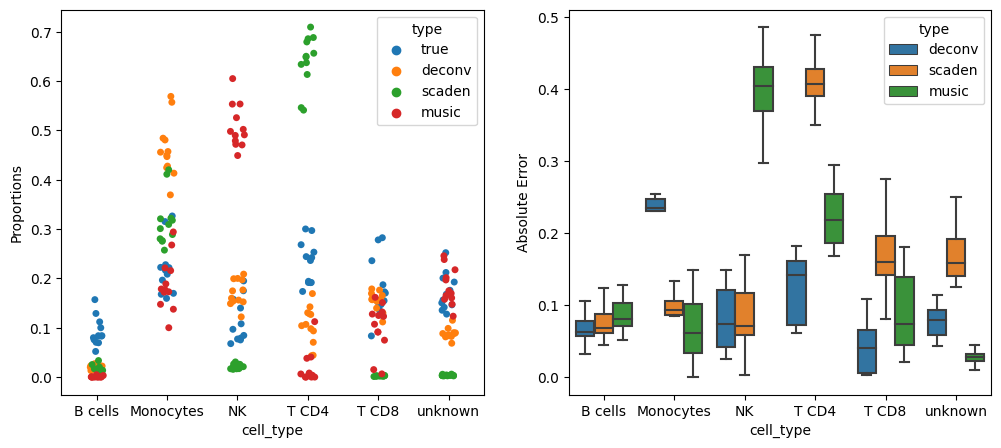

In [42]:
f, ax = plt.subplots(1,2, figsize=(12,5), dpi=100)

sns.stripplot(data=df, x="cell_type", y="proportion", hue="type", ax=ax[0])
# sns.violinplot(data=df, x="cell_type", y="proportion", hue="type", ax=ax[0], showfliers=False, split=True)
sns.boxplot(data=df[df["type"] != "true"], x="cell_type", y="error", hue="type", ax=ax[1], showfliers=False)
# sns.swarmplot(data=df[df["type"] != "true"], x="cell_type", y="error", hue="type", ax=ax[1])
# sns.violinplot(data=melt, x="cell_type", y="dist", ax=ax[1], showfliers=True)
ax[0].set_ylabel("Proportions")
ax[1].set_ylabel("Absolute Error")
# l = plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

<AxesSubplot: xlabel='type', ylabel='error'>

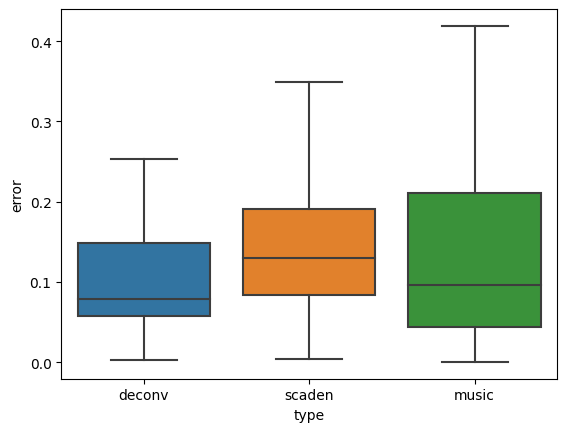

In [45]:
sns.boxplot(data=df[df["type"] != "true"], y="error", x="type", showfliers=False)